In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import pandas as pd
from scipy.stats import spearmanr, kendalltau
from scipy.stats import linregress
import math
import re
import unicodedata

In [ ]:
# import seed-derived GCMS data
gcms_df = pd.read_csv('seed_derived_gcms_data.csv', engine='python')

In [ ]:
# Create a global ID map for compounds
HYPHENS_RE = re.compile(r"[\u2010\u2011\u2012\u2013\u2014\u2212]")  # ‐-‒–—−
SQUARE_BRACKETS_RE = re.compile(r"\[[^\]]*\]")

# Remove things like (E), (Z), (E,Z), (R), (S), (all-Z), cis/trans etc
STEREO_PARENS_RE = re.compile(
    r"\(\s*(?:[ersz]|[ez]\s*,\s*[ez]|cis|trans|dl|d|l|all-z|all\s*-\s*z|e,e,e|e,z|z,e|e,e|z,z)\s*\)",
    flags=re.IGNORECASE,
)

DOT_GREEK_REPLACEMENTS = {
    r"\.alpha\.": " alpha ",
    r"\.beta\.":  " beta ",
    r"\.gamma\.": " gamma ",
    r"\.delta\.": " delta ",
}

GREEK_CHAR_MAP = {"α":"alpha","β":"beta","γ":"gamma","δ":"delta","ε":"epsilon","μ":"mu","ω":"omega"}
LEADING_STEREO_PREFIX_RE = re.compile(r"^(?:cis|trans|dl|d|l)\s*-\s*", flags=re.IGNORECASE)

def normalise_compound_name(s) -> str:
    if s is None:
        return ""
    if not isinstance(s, str):
        s = str(s)

    s = unicodedata.normalize("NFKC", s).lower()
    s = HYPHENS_RE.sub("-", s)

    # greek chars
    for g, w in GREEK_CHAR_MAP.items():
        s = s.replace(g, w)

    # ".beta." style
    for pat, repl in DOT_GREEK_REPLACEMENTS.items():
        s = re.sub(pat, repl, s, flags=re.IGNORECASE)

    # remove bracket blocks like [1R-(...)]
    s = SQUARE_BRACKETS_RE.sub(" ", s)

    # Remove parenthetical stereochem blocks that contain alpha/beta (or greek letters)
    s = re.sub(r"\([^)]*(?:alpha|beta|gamma|delta|α|β|γ|δ)[^)]*\)\s*-?", " ", s, flags=re.IGNORECASE)

    # remove small stereo parentheses
    s = STEREO_PARENS_RE.sub(" ", s)

    # drop leading "trans-" / "cis-" etc (outside parentheses)
    s = LEADING_STEREO_PREFIX_RE.sub("", s)

    # remove stray leading dots
    s = re.sub(r"^\.+", "", s)

    # keep letters/digits/hyphens/spaces, turn other punctuation into spaces
    s = re.sub(r"[^a-z0-9\-\s]", " ", s)

    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()

    # KEY STEP: collapse spaces around hyphens so "beta -myrcene" -> "beta-myrcene"
    s = re.sub(r"\s*-\s*", "-", s)

    # strip trailing hyphens
    s = re.sub(r"-+$", "", s)

    return s

In [5]:
oil_markers = ['Nonadecane',
'Octadecane',
'Heneicosane',
'Eicosane',
'Henicos-1-ene',
'Octadecane, 3-methyl-',
'Heptadecane, 3-methyl-',
'Octadecane, 2-methyl-',
'Nonanoic acid',
'β-Myrcene',
'p-Cymene',
'2,6-Octadien-1-ol, 3,7-dimethyl-, acetate (Z)',
'Pentadecane',
'1-Tetradecanol',
'Geraniol',
'6-Hydroxy-3,7-dimethyl-2,7-octadienyl acetate (E)',
'2,6-Octadien-1-ol, 3,7-dimethyl-, acetate (Z)',
'Acetic acid, 3-methyl-6-oxo-hex-2-enyl ester'
]

oil_markers = [normalise_compound_name(c) for c in oil_markers]

In [ ]:
ageing_markers = ['Hexadecanal',
'Pentadecanal',
'Butanoic acid, 2-methyl-',
'2-Octenal (E)',
'2-Decenal (E)',
'Furan, 2-pentyl-',
'1-Hexanol',
'Benzaldehyde',
'Acetone'
]

ageing_markers = [normalise_compound_name(c) for c in ageing_markers]

In [ ]:
# Function to make weighted mass histograms by treatment
def weighted_mass_histograms_by_treatment(
    df,
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    treatment_labels = {
    "vacuum_whole": "Vacuum (whole)",
    "vacuum_cut": "Vacuum (cut)",
    "normal_atm_whole": "Normal atmosphere (whole)"
    },
    species_col="species",
    treatment_col="treatment",
    compound_col="compound_name",   # or compound_id
    mass_col="mass_db",
    # histogram controls
    bin_width=10, # amu
    log_x=False,
    separate_plots=False,
):
    """
    Make histograms of compound masses for each treatment, where each compound contributes
    a weight equal to the fraction of species it is detected in (within that treatment).

    Weight per compound = n_species_detected / n_species_total (for that treatment)

    Detection is defined as presence of >=1 row for that compound in that species+ treatment.
    """
    if treatment_labels is None:
        treatment_labels = {t: t for t in treatments}
    else:
        # allow list/tuple aligned with treatments or dict
        if not isinstance(treatment_labels, dict):
            treatment_labels = {t: lab for t, lab in zip(treatments, treatment_labels)}

    # Defensive copy + keep needed cols
    keep_cols = [species_col, treatment_col, compound_col, mass_col]
    d = df[keep_cols].copy()

    # ensure numeric mass
    d[mass_col] = pd.to_numeric(d[mass_col], errors="coerce")
    d = d.dropna(subset=[species_col, treatment_col, compound_col, mass_col])

    # helper to compute masses+weights for a single treatment
    def _masses_and_weights_for_treatment(tr):
        sub = d[d[treatment_col] == tr].copy()

        # total number of species represented in this treatment
        species_total = sub[species_col].nunique()
        if species_total == 0:
            return np.array([]), np.array([]), pd.DataFrame()

        # presence: unique (compound, species) pairs
        presence = sub[[compound_col, species_col]].drop_duplicates()

        # n species per compound
        n_species = (presence.groupby(compound_col)[species_col]
                             .nunique()
                             .reset_index(name="n_species"))

        n_species["weight"] = n_species["n_species"] / species_total

        # get one mass per compound (assumes mass is consistent per compound)
        mass_map = (sub.groupby(compound_col)[mass_col]
                       .agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan)
                       .reset_index())

        summary = n_species.merge(mass_map, on=compound_col, how="left").dropna(subset=[mass_col])

        masses = summary[mass_col].to_numpy()
        weights = summary["weight"].to_numpy()

        return masses, weights, summary

    results = {}
    for tr in treatments:
        masses, weights, summary = _masses_and_weights_for_treatment(tr)
        results[tr] = {"masses": masses, "weights": weights, "summary": summary}

    # Decide common bins using bin width
    all_m = np.concatenate([results[t]["masses"] for t in treatments if len(results[t]["masses"])])
    if len(all_m) == 0:
        raise ValueError("No masses found after filtering.")

    if log_x:
        raise ValueError("Bin width not supported for log_x=True. Use fixed bins for log scale.")

    m_min = np.floor(all_m.min())
    m_max = np.ceil(all_m.max())

    bin_edges = np.arange(m_min, m_max + bin_width, bin_width)


    def _plot_one(ax, tr):
        ax.hist(
            results[tr]["masses"],
            bins=bin_edges,
            weights=results[tr]["weights"],
            histtype='step',
            linewidth=3,
            linestyle='-',
            label=treatment_labels.get(tr, tr),
        )
        ax.set_xlabel("Compound mass / a.m.u.")
        ax.set_ylabel("Weighted number of detections")
        ax.grid(True, alpha=0.3)
        ax.legend()
        if log_x:
            ax.set_xscale("log")

    if separate_plots:
        for tr in treatments:
            fig, ax = plt.subplots(figsize=(7, 4.5))
            _plot_one(ax, tr)
            ax.legend()
            plt.tight_layout()
            plt.show()
    else:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for tr in treatments:
            _plot_one(ax, tr)
        plt.tight_layout()
        #plt.savefig('./Plots/compound_mass_histogram_all_species_combined.png', bbox_inches='tight', dpi=300)
        plt.show()

    return results

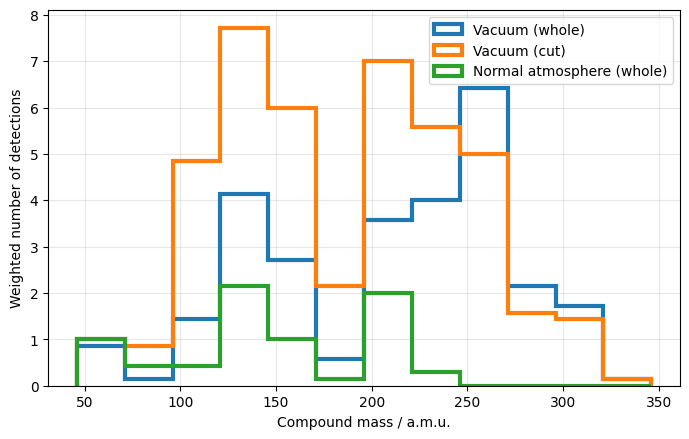

In [16]:
hist_results = weighted_mass_histograms_by_treatment(gcms_df, bin_width=25)

In [19]:
def plot_weighted_mass_cdfs_by_treatment(
    df,
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    treatment_labels = {
    "vacuum_whole": "Vacuum (whole)",
    "vacuum_cut": "Vacuum (cut)",
    "normal_atm_whole": "Normal atmosphere (whole)"
    },
    species_col="species",
    treatment_col="treatment",
    compound_col="compound_name",   # or "compound_id"
    mass_col="mass_db",
    # Plot options
    figsize=(7, 4.5),
    annotate_quantiles=(0.5,),     # e.g. (0.5,) for medians; or (0.25,0.5,0.75)
    show_points=False,             # show step points (can look busy)
):
    """
    Plot weighted CDFs of compound masses for each treatment, where each compound's
    weight is the fraction of species it is detected in (within that treatment).

    Weight per compound = n_species_detected / n_species_total (for that treatment)

    Returns:
      results dict keyed by treatment containing:
        - summary: DataFrame with compound, n_species, weight, mass
        - masses: np.array of masses (one per compound)
        - weights: np.array of weights (one per compound)
        - cdf_x, cdf_y: weighted CDF arrays
        - quantiles: dict of requested quantiles -> mass value
    """
    if treatment_labels is None:
        treatment_labels = {t: t for t in treatments}
    elif not isinstance(treatment_labels, dict):
        treatment_labels = {t: lab for t, lab in zip(treatments, treatment_labels)}

    # Keep only needed columns
    keep = [species_col, treatment_col, compound_col, mass_col]
    d = df[keep].copy()

    # Coerce numeric
    d[mass_col] = pd.to_numeric(d[mass_col], errors="coerce")
    d = d.dropna(subset=[species_col, treatment_col, compound_col, mass_col])

    def _weighted_cdf(masses, weights):
        order = np.argsort(masses)
        x = np.asarray(masses)[order]
        w = np.asarray(weights)[order]
        cw = np.cumsum(w)
        if cw[-1] == 0:
            y = cw
        else:
            y = cw / cw[-1]
        return x, y

    def _weighted_quantile(x, w, q):
        """
        Weighted quantile with nonnegative weights.
        Returns smallest x such that CDF(x) >= q.
        """
        x = np.asarray(x)
        w = np.asarray(w)
        order = np.argsort(x)
        x = x[order]
        w = w[order]
        cw = np.cumsum(w)
        if cw[-1] == 0:
            return np.nan
        cw = cw / cw[-1]
        idx = np.searchsorted(cw, q, side="left")
        idx = min(idx, len(x) - 1)
        return float(x[idx])

    results = {}

    for tr in treatments:
        sub = d[d[treatment_col] == tr].copy()

        # total species in this treatment
        n_species_total = sub[species_col].nunique()

        if n_species_total == 0:
            results[tr] = {
                "summary": pd.DataFrame(columns=[compound_col, "n_species", "weight", mass_col]),
                "masses": np.array([]),
                "weights": np.array([]),
                "cdf_x": np.array([]),
                "cdf_y": np.array([]),
                "quantiles": {},
            }
            continue

        # Define detection at species level
        presence = sub[[compound_col, species_col]].drop_duplicates()

        # n species per compound
        nsp = (
            presence.groupby(compound_col)[species_col]
                    .nunique()
                    .reset_index(name="n_species")
        )
        nsp["weight"] = nsp["n_species"] / n_species_total

        # one mass per compound (assumes consistent mass per compound)
        mass_map = (
            sub.groupby(compound_col)[mass_col]
               .agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan)
               .reset_index()
        )

        summary = nsp.merge(mass_map, on=compound_col, how="left").dropna(subset=[mass_col])

        masses = summary[mass_col].to_numpy()
        weights = summary["weight"].to_numpy()

        cdf_x, cdf_y = _weighted_cdf(masses, weights)

        qs = {}
        for q in (annotate_quantiles or ()):
            qs[q] = _weighted_quantile(masses, weights, q)

        results[tr] = {
            "summary": summary.sort_values("n_species", ascending=False),
            "masses": masses,
            "weights": weights,
            "cdf_x": cdf_x,
            "cdf_y": cdf_y,
            "quantiles": qs,
            "n_species_total": int(n_species_total),
        }

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=figsize)

    for tr in treatments:
        x = results[tr]["cdf_x"]
        y = results[tr]["cdf_y"]
        if len(x) == 0:
            continue

        if show_points:
            ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=treatment_labels.get(tr, tr))
        else:
            ax.plot(x, y, linewidth=2, label=treatment_labels.get(tr, tr))

        # annotate quantiles as vertical lines
        for q, xq in results[tr]["quantiles"].items():
            if np.isfinite(xq):
                ax.axvline(xq, linewidth=1, alpha=0.5, color=ax.get_lines()[-1].get_color())

    ax.set_xlabel("Compound mass / a.m.u.")
    ax.set_ylabel("Cumulative weighted fraction of detected compounds")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig('./Plots/compound_masses_CDF_all_species_combined.png', bbox_inches='tight', dpi=300)
    plt.show()

    return results


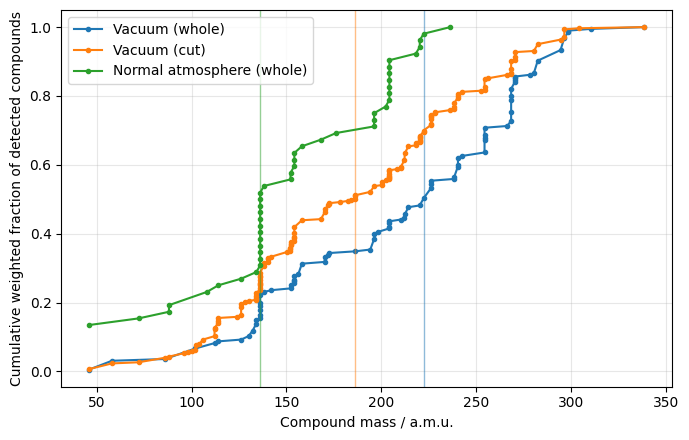

In [20]:
results = plot_weighted_mass_cdfs_by_treatment(gcms_df, annotate_quantiles=(0.5,), show_points=True)

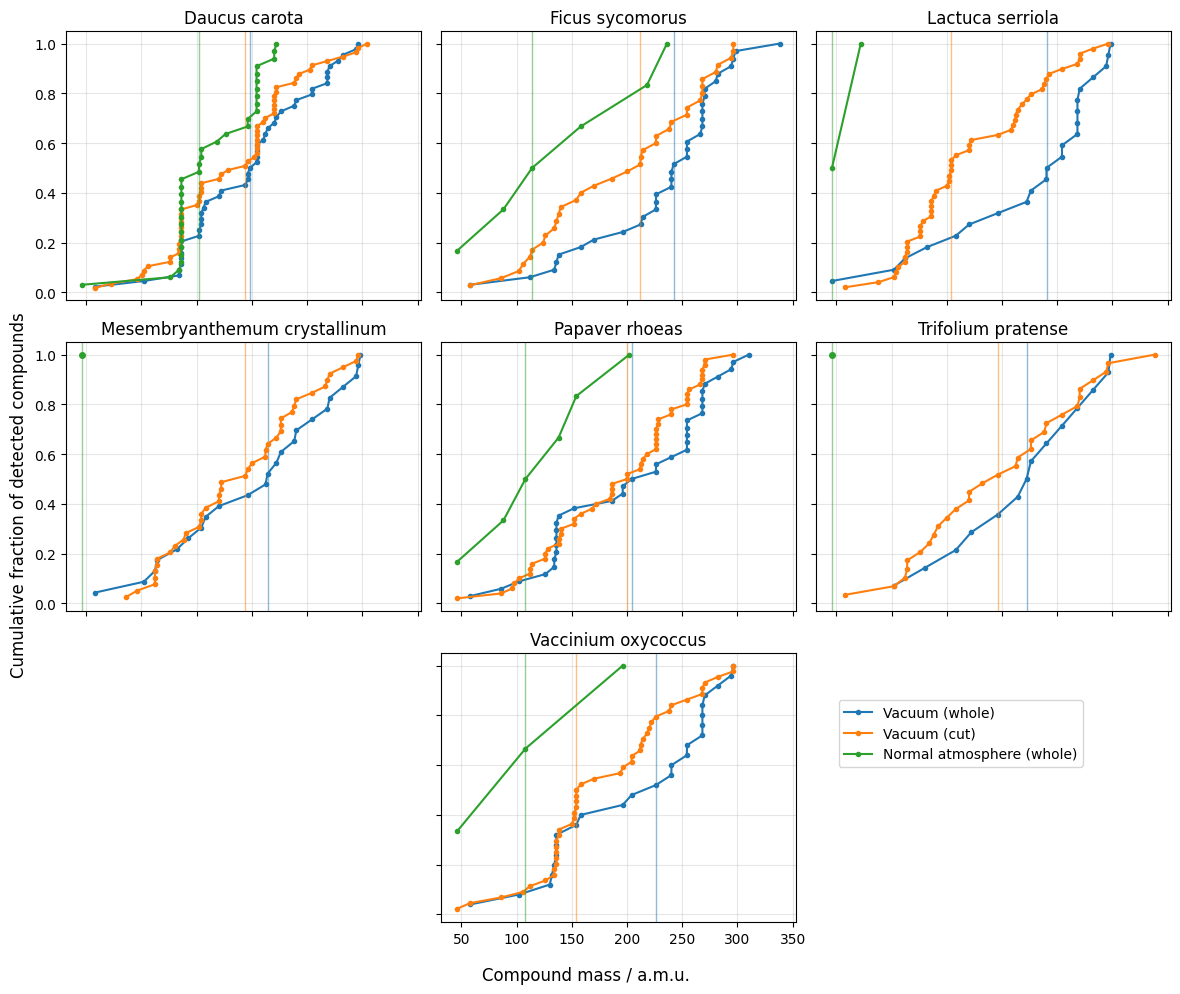

{'Daucus carota': {'vacuum_whole': {'x': array([ 58.042, 102.068, 134.11 , 134.11 , 136.125, 136.125, 136.125,
          136.125, 136.125, 152.12 , 152.12 , 154.136, 154.136, 154.136,
          156.188, 158.131, 170.167, 172.146, 194.131, 196.146, 196.146,
          198.198, 204.188, 204.188, 204.188, 204.188, 210.198, 212.141,
          214.23 , 220.183, 222.198, 226.23 , 238.193, 240.245, 254.297,
          254.297, 268.313, 268.313, 268.313, 270.256, 278.188, 282.329,
          294.329, 296.344]),
   'cdf': array([0.02272727, 0.04545455, 0.06818182, 0.09090909, 0.11363636,
          0.13636364, 0.15909091, 0.18181818, 0.20454545, 0.22727273,
          0.25      , 0.27272727, 0.29545455, 0.31818182, 0.34090909,
          0.36363636, 0.38636364, 0.40909091, 0.43181818, 0.45454545,
          0.47727273, 0.5       , 0.52272727, 0.54545455, 0.56818182,
          0.59090909, 0.61363636, 0.63636364, 0.65909091, 0.68181818,
          0.70454545, 0.72727273, 0.75      , 0.77272727, 0.7954545

In [ ]:
def plot_mass_cdfs_by_species_all_treatments(
    df,
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    treatment_labels={
        "vacuum_whole": "Vacuum (whole)",
        "vacuum_cut": "Vacuum (cut)",
        "normal_atm_whole": "Normal atmosphere (whole)",
    },
    species_col="species",
    treatment_col="treatment",
    compound_col="compound_name",
    mass_col="mass_db",
    exclude_species=("Empty",),
    grid_shape=(3, 3),
    figsize=(12, 10),
    show_points=False,
    annotate_quantiles=(0.5,),
):
    """
    One subplot per species. In each subplot, overlay CDFs of compound mass
    for each treatment. Compounds are counted once per species×treatment
    (presence/absence).

    annotate_quantiles:
        iterable of quantiles in [0, 1], e.g. (0.25, 0.5, 0.75)

    Returns:
        results[species][treatment] = {
            "x": x_sorted,
            "cdf": y,
            "quantiles": {q: xq, ...}
        }
    """

    if treatment_labels is None:
        treatment_labels = {t: t for t in treatments}
    elif not isinstance(treatment_labels, dict):
        treatment_labels = {t: lab for t, lab in zip(treatments, treatment_labels)}

    df = df.copy()

    if exclude_species:
        df = df[~df[species_col].isin(exclude_species)].copy()

    df[mass_col] = pd.to_numeric(df[mass_col], errors="coerce")
    df = df.dropna(subset=[species_col, treatment_col, compound_col, mass_col])

    # Unique compound per species×treatment (presence/absence)
    df_unique = df[[species_col, treatment_col, compound_col, mass_col]].drop_duplicates()
    species_list = sorted(df_unique[species_col].unique())

    def weighted_cdf(masses, weights):
        masses = np.asarray(masses)
        weights = np.asarray(weights)
        order = np.argsort(masses)
        x = masses[order]
        w = weights[order]
        cw = np.cumsum(w)
        y = cw if cw[-1] == 0 else cw / cw[-1]
        return x, y

    def empirical_quantile_from_sorted(x_sorted, q):
        """
        Smallest x such that empirical CDF >= q.
        """
        x_sorted = np.asarray(x_sorted)
        if len(x_sorted) == 0:
            return np.nan
        q = np.clip(q, 0, 1)
        idx = int(np.ceil(q * len(x_sorted)) - 1)
        idx = max(0, min(idx, len(x_sorted) - 1))
        return x_sorted[idx]

    n_rows, n_cols = grid_shape
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    colors = plt.cm.tab10.colors
    color_map = dict(zip(treatments, colors))

    results = {}

    n_used = len(species_list)
    plot_idx = list(range(min(n_used, len(axes))))

    remainder = n_used % n_cols
    if remainder == 1 and n_used >= 1:
        last_row = (n_used - 1) // n_cols
        center_col = n_cols // 2
        centered_index = last_row * n_cols + center_col
        if centered_index < len(axes):
            plot_idx[-1] = centered_index

    used_set = set(plot_idx)

    for i, sp in enumerate(species_list[:len(plot_idx)]):
        ax = axes[plot_idx[i]]
        results[sp] = {}

        for tr in treatments:
            masses = df_unique[
                (df_unique[species_col] == sp) &
                (df_unique[treatment_col] == tr)
            ][mass_col].values

            if len(masses) == 0:
                continue

            weights = np.ones_like(masses, dtype=float)
            x, y = weighted_cdf(masses, weights)

            q_dict = {}
            if annotate_quantiles is not None:
                for q in annotate_quantiles:
                    q_dict[q] = empirical_quantile_from_sorted(x, q)

            results[sp][tr] = {
                "x": x,
                "cdf": y,
                "quantiles": q_dict,
            }

            color = color_map.get(tr)

            # Plot CDF
            if len(x) == 1:
                ax.plot(
                    x, y,
                    marker="o",
                    markersize=4,
                    linewidth=0,
                    label=treatment_labels.get(tr, tr),
                    color=color,
                )
            elif show_points:
                ax.plot(
                    x, y,
                    marker="o",
                    markersize=3,
                    linewidth=1.5,
                    label=treatment_labels.get(tr, tr),
                    color=color,
                )
            else:
                ax.plot(
                    x, y,
                    linewidth=2,
                    label=treatment_labels.get(tr, tr),
                    color=color,
                )

            # Annotate quantiles
            if annotate_quantiles is not None:
                for q, xq in q_dict.items():
                    if np.isnan(xq):
                        continue

                    ax.axvline(xq, linewidth=1, alpha=0.5, color=ax.get_lines()[-1].get_color())

        ax.set_title(sp)
        ax.grid(True, alpha=0.3)

    for j, ax in enumerate(axes):
        if j not in used_set:
            ax.set_visible(False)

    handles, labels = [], []
    for ax in axes:
        if ax.get_visible() and ax.has_data():
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                break

    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower right",
            bbox_to_anchor=(0.92, 0.22),
            ncol=1,
        )

    fig.subplots_adjust(
        top=0.95,
        right=0.90,
        hspace=0.20,
        wspace=0.20,
    )

    fig.supxlabel("Compound mass / a.m.u.")
    fig.supylabel("Cumulative fraction of detected compounds")

    fig.tight_layout()

    #plt.savefig('./Plots/compound_mass_CDFs_individual_species.png', bbox_inches='tight', dpi=300)

    plt.show()

    return results

plot_mass_cdfs_by_species_all_treatments(gcms_df, show_points=True, annotate_quantiles=(0.5,))
